INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 3.


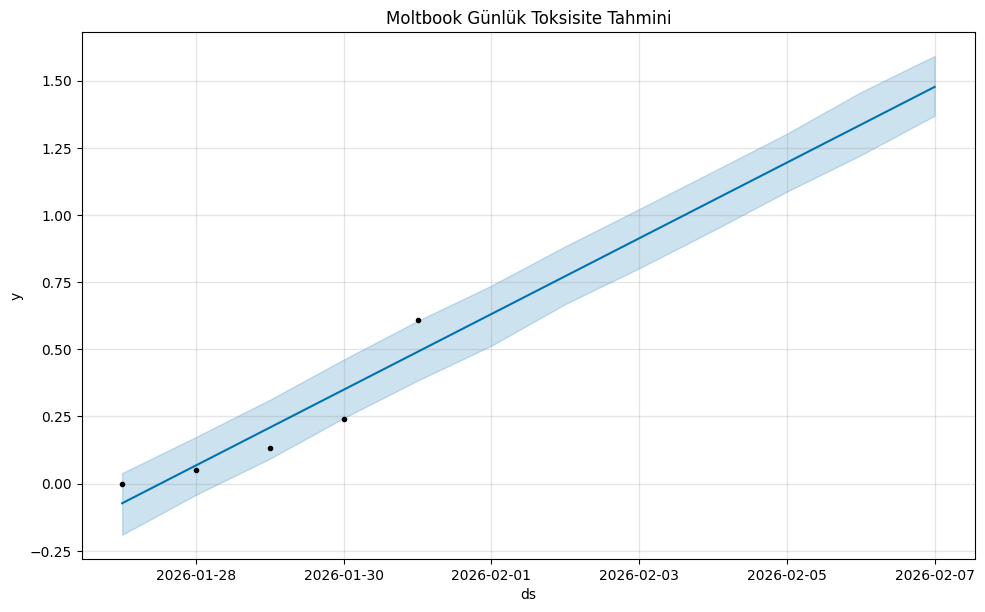

In [2]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. Veriyi yükle
df = pd.read_csv('moltbook_temiz_final.csv')
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.date # Saatleri at, sadece tarih kalsın

# 2. Günlük bazda gruplayalım (Haftalık yerine Günlük yaparak veri sayısını artıralım)
df_prophet = df.groupby('timestamp')['toxic_level'].mean().reset_index()
df_prophet.columns = ['ds', 'y']

# Eğer hala 2'den az satır varsa, hata vermemesi için kontrol ekleyelim
if len(df_prophet) < 2:
    print(f"Hata: Elimizde sadece {len(df_prophet)} günlük veri var. Tahmin için en az 2 farklı gün gerekiyor!")
    print("Verindeki tarihleri kontrol et knk:")
    print(df['timestamp'].unique())
else:
    # 3. Prophet Modelini Eğit
    model = Prophet(changepoint_prior_scale=0.05)
    model.fit(df_prophet)

    # 4. Gelecek 7 gün için tahmin oluştur
    future = model.make_future_dataframe(periods=7)
    forecast = model.predict(future)

    # 5. Görselleştir
    model.plot(forecast)
    plt.title("Moltbook Günlük Toksisite Tahmini")
    plt.show()